In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import brainmass
import brainstate
import brainunit as u
import jax
import jax.numpy as jnp
import numpy as np
brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Forward Modeling

Forward models map neural activity to observable neuroimaging signals (BOLD, EEG, MEG).

:::{note}
Every code cell on this page is executed against the current API. The examples use
small, synthesized inputs (random row-normalised connectivity, random lead-field
matrices) so they run quickly and self-contained; swap in your own structural
connectivity and BEM-derived lead fields for real studies. For more forward-model
context see the Balloon-Windkessel BOLD section of {doc}`/getting_started/quickstart` and the
`LeadFieldModel` examples in {doc}`../reference/forward`.
:::

## Overview

```text
Neural Mass Model → Forward Model → Neuroimaging Signal
(hidden dynamics)   (biophysics)    (observable data)
```

Three main forward models:

1. **BOLD**: fMRI hemodynamic response
2. **EEG**: Electric scalp potentials
3. **MEG**: Magnetic field sensors

## BOLD Signal Modeling

### Basic BOLD Workflow

The neural driver here is the reduced Wong-Wang excitatory-inhibitory mean-field model
(`WongWangExcInhStep`) -- the standard resting-state / BOLD workhorse. Its excitatory
gating variable `S_e` feeds the Balloon-Windkessel `BOLDSignal` model. The neural stage
integrates with a time-unit `dt`; `BOLDSignal` is dimensionless and uses a unitless `dt`,
so the two stages set `dt` separately (as in the {doc}`/getting_started/quickstart` BOLD example).

In [2]:
import brainmass
import brainstate
import brainunit as u
import numpy as np

N_regions = 8

# --- neural stage (dt carries time units) ---
brainstate.environ.set(dt=0.1 * u.ms)

# 1. Create neural mass model (reduced Wong-Wang E-I, the resting-state workhorse)
nmm = brainmass.WongWangExcInhStep(in_size=N_regions)
nmm.init_all_states()

# 2. Simulate neural activity; update() returns the excitatory gating S_e
def sim_neural(i):
    with brainstate.environ.context(i=i, t=i * brainstate.environ.get_dt()):
        return nmm.update()  # no network coupling here

neural_activity = brainstate.transform.for_loop(
    sim_neural,
    np.arange(2000)  # 2000 steps; keep modest so the example runs fast
)
# neural_activity has shape (2000, 8)

# --- haemodynamic stage (BOLDSignal needs a dimensionless dt) ---
brainstate.environ.set(dt=0.01)

# 3. Create the Balloon-Windkessel BOLD hemodynamic model
bold = brainmass.BOLDSignal(in_size=N_regions)
bold.init_all_states()

# 4. Generate the BOLD signal (update() mutates state, bold() reads the observable)
def sim_bold(z):
    bold.update(z)
    return bold.bold()

bold_signal = brainstate.transform.for_loop(sim_bold, neural_activity)
# bold_signal has shape (2000, 8)

brainstate.environ.set(dt=0.1 * u.ms)  # restore the time-unit dt

print("neural_activity:", neural_activity.shape)
print("bold_signal:", bold_signal.shape)

neural_activity: (2000, 8)
bold_signal: (2000, 8)


### Complete fMRI Simulation

A whole-brain resting-state simulation: a network of `WongWangExcInhStep` nodes coupled
through a structural connectivity matrix, fed into the BOLD model. We then compute the
simulated functional connectivity (FC) and compare it to a (synthesized) empirical FC.

`DiffusiveCoupling` reads each node's `S_e` through a *prefetch* (here delayed by 1 ms),
multiplies by the connectivity, and returns a per-node coupling current that we pass into
`update()`. Per-region Ornstein-Uhlenbeck noise on the excitatory pool gives each region
its own fluctuations (the deterministic model would otherwise collapse to a single shared
fixed point and yield a degenerate FC). In a real study you would replace the random
connectivity and the synthetic empirical FC with your own structural connectome and
measured FC.

In [3]:
import brainmass
import brainstate
import braintools
import brainunit as u
import numpy as np
import jax.numpy as jnp

# Parameters (small + short so the docs build stays fast)
N = 8
brainstate.random.seed(42)  # make the noise reproducible

# --- structural connectivity: random, no self-connections, row-normalised ---
W = np.asarray(np.random.RandomState(0).rand(N, N))
np.fill_diagonal(W, 0.0)
W = jnp.asarray(W / W.sum(axis=1, keepdims=True))

# --- neural stage ---
brainstate.environ.set(dt=0.1 * u.ms)
# Per-region OU noise on the excitatory pool drives heterogeneous fluctuations,
# without which the deterministic nodes converge to one shared fixed point.
nodes = brainmass.WongWangExcInhStep(
    in_size=N, G=2.0,
    noise_e=brainmass.OUProcess(in_size=N, sigma=0.01, tau=100. * u.ms),
)

# Each target node reads every source node's (1 ms-delayed) S_e -> shape (N, N)
delays = jnp.ones((N, N)) * (1.0 * u.ms)
src_idx = np.tile(np.arange(N)[None, :], (N, 1))
s_delayed = nodes.prefetch_delay('S_e', delays, src_idx, init=braintools.init.Constant(0.001))
s_local = nodes.prefetch('S_e')
coupling = brainmass.DiffusiveCoupling(s_delayed, s_local, conn=W, k=1.0)

nodes.init_all_states()
coupling.init_all_states()  # the coupling owns the delay buffer

def neural_step(i):
    with brainstate.environ.context(i=i, t=i * brainstate.environ.get_dt()):
        coupled_input = coupling.update()   # (N,) coupling current
        return nodes.update(coupled_input)  # advance and return S_e

neural_ts = brainstate.transform.for_loop(neural_step, np.arange(2000))

# --- haemodynamic stage ---
brainstate.environ.set(dt=0.01)
bold = brainmass.BOLDSignal(in_size=N)
bold.init_all_states()

def bold_step(z):
    bold.update(z)
    return bold.bold()

bold_ts = brainstate.transform.for_loop(bold_step, neural_ts)
brainstate.environ.set(dt=0.1 * u.ms)  # restore the time-unit dt

# Discard the initial transient, then compute the simulated FC
bold_fmri = bold_ts[200:]
FC_sim = jnp.corrcoef(bold_fmri.T)

# Compare to a synthesized "empirical" FC (here: FC implied by the structural matrix).
# In practice load your measured FC instead.
FC_emp = jnp.corrcoef(np.asarray(W) + np.asarray(W).T)
correlation = jnp.corrcoef(FC_sim.flatten(), FC_emp.flatten())[0, 1]
print(f"FC_sim shape: {FC_sim.shape}")
print(f"FC correlation (sim vs synthetic empirical): {float(correlation):.3f}")

FC_sim shape: (8, 8)
FC correlation (sim vs synthetic empirical): 0.248


## EEG/MEG Modeling

### Lead-Field Setup

A lead-field matrix `L` of shape `(N_sources, N_sensors)` maps region-level dipole
moments to sensor space. `EEGLeadFieldModel` expects `L` in units of **V / (nA·m)** and,
by default, maps a millivolt source observable to a dipole moment internally
(`scale = nA·m / mV`), so its `update()` output is in volts. Here we synthesize a random
lead field; in a real study `L` comes from a BEM/forward head model.

In [4]:
import brainmass
import brainunit as u
import numpy as np
import jax.numpy as jnp

N_sources = 6   # cortical regions
N_sensors = 8   # EEG electrodes

# Lead-field matrix L[j, i] = source j -> sensor i sensitivity.
# Synthesized here (random); load from your head model in practice.
# Units: V / (nA*m)
L_eeg = jnp.asarray(np.random.RandomState(1).randn(N_sources, N_sensors)) * (u.volt / (u.nA * u.meter))

# Create the EEG forward model (in_size = sources, out_size = sensors)
eeg_model = brainmass.EEGLeadFieldModel(
    in_size=(N_sources,),
    out_size=(N_sensors,),
    L=L_eeg,
)
print("L_eeg shape:", L_eeg.shape, "unit:", u.get_unit(L_eeg))

L_eeg shape: (6, 8) unit: V / (m * nA)


### EEG Simulation

The Jansen-Rit model generates EEG-like cortical signals: its pyramidal output `M`
(returned by `update()`, in mV) is the natural source observable. We simulate the source
activity, then project the whole `(T, N_sources)` time series to sensors in one call --
`LeadFieldModel.update` maps over the leading (time) axis automatically.

In [5]:
import brainmass
import brainstate
import brainunit as u
import numpy as np

brainstate.environ.set(dt=0.1 * u.ms)

# Jansen-Rit model (generates EEG-like signals)
nmm = brainmass.JansenRitStep(in_size=N_sources)
nmm.init_all_states()

# Simulate source activity; update() returns the pyramidal output M (mV)
def sim_sources(i):
    with brainstate.environ.context(i=i, t=i * brainstate.environ.get_dt()):
        return nmm.update(E_inp=220. * u.Hz)  # excitatory drive to the pyramidal pool

source_activity = brainstate.transform.for_loop(
    sim_sources,
    np.arange(2000)
)
# source_activity shape: (2000, N_sources), unit mV

# Project to sensors (maps over the leading time axis)
eeg_sensors = eeg_model.update(source_activity)
# eeg_sensors shape: (2000, N_sensors), unit V
print("source_activity:", source_activity.shape, u.get_unit(source_activity))
print("eeg_sensors:", eeg_sensors.shape, u.get_unit(eeg_sensors))

source_activity: (2000, 6) mV
eeg_sensors: (2000, 8) V


### MEG Simulation

MEG uses a lead field in **T / (nA·m)** and reports field strength in tesla. We reuse the
same Jansen-Rit `source_activity` (mV) and build the forward operator with the general
`LeadFieldModel`, supplying an explicit `scale` that maps the millivolt observable to a
dipole moment (nA·m) so the output comes out in tesla.

In [6]:
import brainmass
import brainunit as u
import numpy as np
import jax.numpy as jnp

N_meg_sensors = 10  # e.g. a small magnetometer array

# MEG lead-field, synthesized. Units: T / (nA*m)
L_meg = jnp.asarray(np.random.RandomState(2).randn(N_sources, N_meg_sensors)) * (u.tesla / (u.nA * u.meter))

meg_model = brainmass.LeadFieldModel(
    in_size=(N_sources,),
    out_size=(N_meg_sensors,),
    L=L_meg,
    sensor_unit=u.tesla,
    dipole_unit=u.nA * u.meter,
    scale=2.0 * u.nA * u.meter / u.mV,  # map the mV source observable to a dipole moment
)

# Project the same source activity to MEG sensors
meg_sensors = meg_model.update(source_activity)
# meg_sensors shape: (2000, N_meg_sensors), unit T
print("meg_sensors:", meg_sensors.shape, u.get_unit(meg_sensors))

meg_sensors: (2000, 10) T


## Comparing Modalities

### Simultaneous EEG/MEG/fMRI

Drive all three forward models from the *same* neural source time series. EEG and MEG are
instantaneous linear projections of the pyramidal activity, while BOLD is produced by
integrating the Balloon-Windkessel model and then downsampling to the (much slower) fMRI
sampling rate.

In [7]:
import brainmass
import brainstate
import brainunit as u
import numpy as np
import jax.numpy as jnp

R = N_sources  # reuse the source/sensor counts defined above

# Shared neural source (Jansen-Rit)
brainstate.environ.set(dt=0.1 * u.ms)
nmm = brainmass.JansenRitStep(in_size=R)
nmm.init_all_states()

def source_step(i):
    with brainstate.environ.context(i=i, t=i * brainstate.environ.get_dt()):
        return nmm.update(E_inp=220. * u.Hz)

neural_src = brainstate.transform.for_loop(source_step, np.arange(2000))  # (2000, R) mV

# EEG / MEG: instantaneous linear projections of the same source
eeg_data = eeg_model.update(neural_src)   # (2000, N_sensors) V
meg_data = meg_model.update(neural_src)   # (2000, N_meg_sensors) T

# BOLD: integrate the haemodynamic model, then downsample
brainstate.environ.set(dt=0.01)
bold = brainmass.BOLDSignal(in_size=R)
bold.init_all_states()

def bold_step(z):
    bold.update(z)
    return bold.bold()

# BOLD is driven by a (dimensionless) neural activity; use the magnitude of the source
bold_ts = brainstate.transform.for_loop(bold_step, u.get_magnitude(neural_src))
brainstate.environ.set(dt=0.1 * u.ms)

bold_data = bold_ts[::200]  # coarse downsample to mimic a slow TR
print("eeg_data:", eeg_data.shape, "| meg_data:", meg_data.shape, "| bold_data:", bold_data.shape)

eeg_data: (2000, 8) | meg_data: (2000, 10) | bold_data: (10, 6)


## Advanced Topics

### Handling Units

In [8]:
import brainmass
import brainstate
import brainunit as u

brainstate.environ.set(dt=0.1 * u.ms)

# Inspect the units that flow through the pipeline.
jr = brainmass.JansenRitStep(in_size=N_sources)
jr.init_all_states()
with brainstate.environ.context(i=0, t=0. * u.ms):
    jr.update(E_inp=220. * u.Hz)

# Jansen-Rit pyramidal membrane potential is a unit-carrying state (mV)
V_pyramid = jr.M.value           # mV
print("V_pyramid unit:", u.get_unit(V_pyramid))

# The EEG forward model maps that mV observable to volts at the sensors
eeg_signal = eeg_model.update(V_pyramid[None, :])  # add a time axis -> (1, N_sensors)
print("eeg_signal unit:", u.get_unit(eeg_signal))

# The BOLD model is dimensionless; feed it a plain (unitless) neural activity
neural_rate = u.get_magnitude(V_pyramid)  # strip units for the haemodynamic stage
print("neural_rate (dimensionless) shape:", neural_rate.shape)

V_pyramid unit: mV
eeg_signal unit: V
neural_rate (dimensionless) shape: (6,)


### Custom Forward Models

Implement custom observation functions:

In [9]:
import jax.numpy as jnp

def custom_bold_observation(neural_activity):
    """A toy custom observation model (nonlinear saturation)."""
    return jnp.tanh(neural_activity / 10.0)

# Apply it to the simulated network activity from the fMRI example (S_e is dimensionless)
bold_custom = custom_bold_observation(neural_ts)
print("bold_custom:", bold_custom.shape)

bold_custom: (2000, 8)


## Model Validation

### Comparing to Empirical Data

A common validation metric is the agreement between simulated and empirical functional
connectivity. We reuse `bold_fmri` from the complete fMRI simulation above and compare its
FC against a synthesized empirical FC (replace it with your measured FC in practice),
reporting both the Pearson correlation and the mean squared error.

In [10]:
import numpy as np
import jax.numpy as jnp

# Simulated BOLD FC (from the complete fMRI simulation above)
FC_sim = jnp.corrcoef(bold_fmri.T)

# Synthesized "empirical" FC. In practice: FC_emp = jnp.load('empirical_FC.npy')
rng = np.random.RandomState(3)
noise = rng.randn(*FC_sim.shape) * 0.1
FC_emp = jnp.asarray(np.asarray(FC_sim) + 0.5 * (noise + noise.T))

# Correlation between the two FC matrices
FC_corr = jnp.corrcoef(FC_sim.flatten(), FC_emp.flatten())[0, 1]

# Mean squared error
FC_mse = jnp.mean((FC_sim - FC_emp) ** 2)

print(f"FC correlation: {float(FC_corr):.3f}")
print(f"FC MSE: {float(FC_mse):.3f}")

FC correlation: 0.990
FC MSE: 0.008


### Power Spectral Density

Spectral content is another validation lens. Here we estimate the PSD of one simulated EEG
channel with Welch's method. The neural stage used `dt = 0.1 ms`, so the sampling rate is
10 kHz. (For a real comparison, overlay the PSD of an empirical recording.)

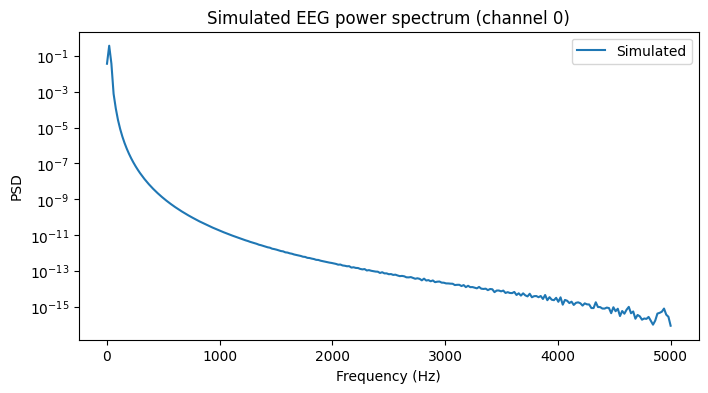

In [11]:
import numpy as np
import brainunit as u
import matplotlib.pyplot as plt
from scipy import signal

# Strip units before handing the signal to scipy; channel 0
channel0 = np.asarray(u.get_magnitude(eeg_sensors[:, 0]))

# Compute PSD of the simulated EEG (neural dt = 0.1 ms -> fs = 10 kHz)
freqs, psd = signal.welch(channel0, fs=10_000, nperseg=512)

plt.figure(figsize=(8, 4))
plt.semilogy(freqs, psd, label='Simulated')
plt.legend()
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
plt.title('Simulated EEG power spectrum (channel 0)')
plt.show()

## Best Practices

1. **Match Timescales**: Use appropriate models for each modality (fast for EEG/MEG, slow for BOLD)
2. **Discard Transients**: Remove initial ~20s for BOLD to reach steady state
3. **Downsample Correctly**: Match sampling rate to modality (TR for fMRI, ms for EEG/MEG)
4. **Validate Lead-Fields**: Check that L has correct shape and units
5. **Use Realistic Parameters**: BOLD hemodynamics have well-established parameter ranges

## Common Issues

**BOLD doesn't stabilize:**

- Run longer simulation (>60s)
- Check initial conditions
- Verify hemodynamic parameters

**EEG/MEG too small/large:**

- Check lead-field units and scaling
- Verify dipole_scale conversion factor
- Ensure biophysically realistic source activity

**Mismatch with empirical data:**

- Adjust coupling strength
- Check structural connectivity
- Tune model parameters (see {doc}`/tutorials/06_fitting_with_gradients`)

## Next Steps

- {doc}`/tutorials/06_fitting_with_gradients` - Optimize parameters to match empirical data
- {doc}`../reference/forward` - Complete forward model API
- {doc}`../gallery/index` - Real data examples

## See Also

- {doc}`/tutorials/04_building_a_network` - Network setup for forward modeling
- {doc}`../reference/forward` - Forward model reference